# Smart Cartoon Pipeline
### Computer Vision Final Project — Academic Notebook
> **Complete end-to-end CV pipeline:** Transfer Learning · CNN from Scratch · Full Evaluation · Model Comparison · Flask Deployment

---

## Section 1 — Imports

In [8]:
import os
import csv
import json
import random
import logging
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s [%(levelname)s] %(message)s',
                    datefmt='%H:%M:%S')
logger = logging.getLogger(__name__)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU available: False


---
## Section 2 — Configuration

In [9]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR        = 'data'
MODELS_DIR      = 'models'
TL_MODEL_PATH   = 'models/real_vs_cartoon_classifier.keras'
SC_MODEL_PATH   = 'models/scratch_model.keras'
SPLIT_TRAIN     = 'models/split_train.csv'
SPLIT_VAL       = 'models/split_val.csv'
SPLIT_TEST      = 'models/split_test.csv'

# ── Image sizes ────────────────────────────────────────────────────────────
TL_IMG_SIZE     = (224, 224)    # MobileNetV2 expects 224×224
SC_IMG_SIZE     = (128, 128)    # Scratch CNN uses 128×128

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE      = 32
EPOCHS_P1       = 10            # Phase 1: frozen backbone
EPOCHS_P2       = 10            # Phase 2: fine-tuning
EPOCHS_SCRATCH  = 30
SEED            = 42

# ── Dataset constants ──────────────────────────────────────────────────────
CLASSES         = {'cartoon': 0, 'real': 1}
IMG_EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
MIN_IMAGES      = 1000
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
# IMBALANCE threshold: warn if any class > this fraction of total
IMBALANCE_THRESHOLD = 0.60

os.makedirs(MODELS_DIR, exist_ok=True)
print('Configuration loaded.')
print(f'  DATA_DIR        : {DATA_DIR}')
print(f'  TL_IMG_SIZE     : {TL_IMG_SIZE}')
print(f'  SC_IMG_SIZE     : {SC_IMG_SIZE}')
print(f'  BATCH_SIZE      : {BATCH_SIZE}')
print(f'  IMBALANCE THRESH: >{IMBALANCE_THRESHOLD*100:.0f}%')

Configuration loaded.
  DATA_DIR        : data
  TL_IMG_SIZE     : (224, 224)
  SC_IMG_SIZE     : (128, 128)
  BATCH_SIZE      : 32
  IMBALANCE THRESH: >60%


---
## Section 3 — Dataset Validation

In [10]:
def is_valid_image(path: str) -> bool:
    """Return True if the file can be decoded by OpenCV without errors."""
    try:
        img = cv2.imread(path)
        return img is not None and img.size > 0
    except Exception:
        return False


def validate_dataset(data_dir: str, min_images: int = MIN_IMAGES) -> dict:
    """
    Scan data_dir/{real,cartoon}, verify counts, skip corrupted files.

    Returns:
        {"real": [...], "cartoon": [...], "stats": {class: {total, valid, corrupted}}}

    Raises SystemExit if any class has fewer than min_images valid images.
    """
    result = {}
    stats  = {}

    for cls, label in CLASSES.items():
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_dir):
            logger.error('Missing class directory: %s', cls_dir)
            raise SystemExit(1)

        all_files = [
            os.path.abspath(os.path.join(cls_dir, f))
            for f in sorted(os.listdir(cls_dir))
            if Path(f).suffix.lower() in IMG_EXTENSIONS
        ]

        valid, corrupted = [], []
        for path in all_files:
            if is_valid_image(path):
                valid.append(path)
            else:
                corrupted.append(path)
                logger.warning('  Skipping corrupted image: %s', path)

        stats[cls] = {
            'total':     len(all_files),
            'valid':     len(valid),
            'corrupted': len(corrupted),
        }

        logger.info('  %-10s → %d valid / %d total (%d corrupted)',
                    cls, len(valid), len(all_files), len(corrupted))

        if len(valid) < min_images:
            logger.error(
                '  ✗ Class \'%s\' has only %d valid images (minimum %d required).',
                cls, len(valid), min_images
            )
            raise SystemExit(1)

        result[cls] = valid

    logger.info('  ✓ Dataset validation passed.')
    return {**result, 'stats': stats}


# Run validation
dataset = validate_dataset(DATA_DIR)
print('\nDataset Summary:')
for cls, info in dataset['stats'].items():
    print(f"  {cls:10s} → {info['valid']:,} valid / {info['total']:,} total")

18:12:51 [INFO]   cartoon    → 1073 valid / 1073 total (0 corrupted)
18:12:52 [INFO]   real       → 1170 valid / 1170 total (0 corrupted)
18:12:52 [INFO]   ✓ Dataset validation passed.



Dataset Summary:
  cartoon    → 1,073 valid / 1,073 total
  real       → 1,170 valid / 1,170 total


---
## Section 4 — Class Balance Analysis
>  Checks whether the dataset is imbalanced and prints informational warnings. Does not modify, delete, or re-split any images.

CLASS BALANCE ANALYSIS
  Total valid images : 2,243

  cartoon   :  1,073 images  ( 47.8%)  ███████████████████████
  real      :  1,170 images  ( 52.2%)  ██████████████████████████

   Dataset is balanced: 47.8% cartoon, 52.2% real


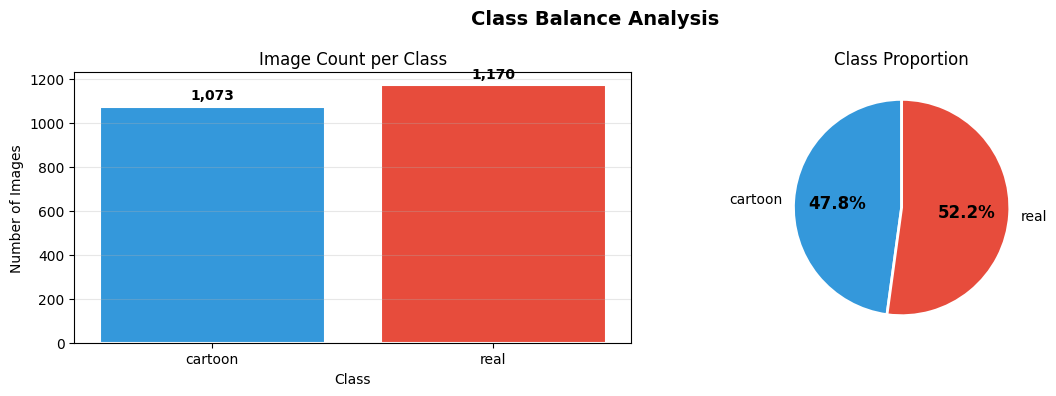

  Chart saved → models/class_balance.png


In [11]:
def check_class_balance(dataset: dict, threshold: float = IMBALANCE_THRESHOLD) -> dict:
    """
    Check class balance and print informational warnings.

    This function is INFORMATIONAL ONLY:
      - Does NOT delete or modify any images.
      - Does NOT change the train/val/test split.
      - Warns if any class exceeds `threshold` fraction of total images.

    Returns:
        dict with per-class counts and percentages.
    """
    counts      = {cls: len(paths) for cls, paths in dataset.items() if cls != 'stats'}
    total       = sum(counts.values())
    percentages = {cls: count / total for cls, count in counts.items()}

    print('=' * 55)
    print('CLASS BALANCE ANALYSIS')
    print('=' * 55)
    print(f'  Total valid images : {total:,}')
    print()

    for cls, count in counts.items():
        pct = percentages[cls] * 100
        bar = '█' * int(pct / 2)
        print(f'  {cls:10s}: {count:>6,} images  ({pct:5.1f}%)  {bar}')

    print()

    # ── Imbalance check ───────────────────────────────────────────────────
    is_imbalanced = any(p > threshold for p in percentages.values())

    if is_imbalanced:
        dominant_cls = max(percentages, key=percentages.get)
        minor_cls    = min(percentages, key=percentages.get)
        pct_dom      = percentages[dominant_cls] * 100
        pct_min      = percentages[minor_cls] * 100

        print(f'    WARNING: Dataset appears imbalanced'
              f' ({pct_dom:.0f}% {dominant_cls} vs {pct_min:.0f}% {minor_cls})')
        print()
        print('  Recommendations (informational — no action taken):')
        print('    • Consider collecting more images for the minority class.')
        print('    • Consider using class_weight in model.fit() during training.')
        print('    • Weighted loss can partially compensate during training.')
    else:
        pct_values = [f'{p*100:.1f}% {cls}' for cls, p in percentages.items()]
        print(f'   Dataset is balanced: {", ".join(pct_values)}')

    print('=' * 55)

    # ── Visual bar chart ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Class Balance Analysis', fontsize=14, fontweight='bold')

    colors = ['#3498db', '#e74c3c']
    classes_list = list(counts.keys())
    count_vals   = list(counts.values())
    pct_vals     = [percentages[c] * 100 for c in classes_list]

    # Bar chart — absolute counts
    bars = axes[0].bar(classes_list, count_vals, color=colors, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Image Count per Class')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_xlabel('Class')
    for bar, val in zip(bars, count_vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                     f'{val:,}', ha='center', va='bottom', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart — proportions
    wedges, texts, autotexts = axes[1].pie(
        pct_vals, labels=classes_list, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
    axes[1].set_title('Class Proportion')

    if is_imbalanced:
        axes[1].set_title('Class Proportion   Imbalanced', color='#c0392b')

    plt.tight_layout()
    plt.savefig('models/class_balance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Chart saved → models/class_balance.png')

    return {'counts': counts, 'percentages': percentages,
            'is_imbalanced': is_imbalanced, 'total': total}


balance_info = check_class_balance(dataset)

---
## Section 5 — Data Preprocessing & Split

In [12]:
def _write_csv(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)


def _read_csv(path):
    rows = []
    with open(path, newline='') as f:
        for row in csv.reader(f):
            rows.append((row[0], int(row[1])))
    return rows


def build_splits(dataset: dict, seed: int = SEED, force_rebuild: bool = False):
    """
    Build or load the 70 / 15 / 15 train/val/test split.
    Splits are saved as CSV so both models share the same split.
    """
    if (not force_rebuild
            and os.path.exists(SPLIT_TRAIN)
            and os.path.exists(SPLIT_VAL)
            and os.path.exists(SPLIT_TEST)):
        logger.info('Loading existing splits from %s', MODELS_DIR)
        return _read_csv(SPLIT_TRAIN), _read_csv(SPLIT_VAL), _read_csv(SPLIT_TEST)

    logger.info('Building new 70/15/15 split (seed=%d) …', seed)
    random.seed(seed)
    train_rows, val_rows, test_rows = [], [], []

    for cls, label in CLASSES.items():
        paths = dataset[cls][:]
        random.shuffle(paths)
        n       = len(paths)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        train_rows += [(p, label) for p in paths[:n_train]]
        val_rows   += [(p, label) for p in paths[n_train:n_train + n_val]]
        test_rows  += [(p, label) for p in paths[n_train + n_val:]]
        logger.info('  %-10s → train=%d  val=%d  test=%d', cls, n_train, n_val, n - n_train - n_val)

    random.shuffle(train_rows)
    random.shuffle(val_rows)
    random.shuffle(test_rows)

    _write_csv(SPLIT_TRAIN, train_rows)
    _write_csv(SPLIT_VAL,   val_rows)
    _write_csv(SPLIT_TEST,  test_rows)
    logger.info('  ✓ Splits saved to %s/', MODELS_DIR)

    return train_rows, val_rows, test_rows


train_rows, val_rows, test_rows = build_splits(dataset)

print(f'\nSplit Summary (70 / 15 / 15):')
for name, rows in [('Train', train_rows), ('Val', val_rows), ('Test', test_rows)]:
    c = {0: 0, 1: 0}
    for _, lbl in rows: c[lbl] += 1
    print(f'  {name:5s}: {len(rows):>5,} total  |  cartoon={c[0]}  real={c[1]}')

18:12:53 [INFO] Loading existing splits from models



Split Summary (70 / 15 / 15):
  Train: 1,570 total  |  cartoon=751  real=819
  Val  :   335 total  |  cartoon=160  real=175
  Test :   338 total  |  cartoon=162  real=176


---
## Section 6 — Data Augmentation
> Added `RandomZoom` (10–15%) and proper small-angle `RandomRotation` (±20° ≈ 0.055 factor).  
> Original augmentations (flip, brightness, contrast, saturation) are preserved unchanged.

In [13]:
# ── Keras augmentation layers (applied inside the tf.data pipeline) ─────────

# NEW: Zoom layer — random zoom between 90% and 110% of original size
zoom_layer     = tf.keras.layers.RandomZoom(
    height_factor=(-0.15, 0.15),   # ±15% zoom
    width_factor=(-0.15, 0.15),
    fill_mode='reflect'
)

# NEW: Rotation layer — small-angle rotation ±20° (factor = 20/360 ≈ 0.055)
rotation_layer = tf.keras.layers.RandomRotation(
    factor=0.055,                   # ±20 degrees  (factor * 360 = degrees)
    fill_mode='reflect'
)


def _load_and_resize(path: tf.Tensor, label: tf.Tensor, img_size: tuple) -> tuple:
    """Read, decode, resize a single image."""
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, label


def _augment(img: tf.Tensor, label: tf.Tensor) -> tuple:
    """
    Augmentation pipeline (training only).

    PRESERVED (original):
      • random_flip_left_right
      • random_brightness
      • random_contrast
      • random_saturation
      • rot90  (90-degree multiples)

    ADDED:
      • RandomZoom    ±15%  — adds scale invariance
      • RandomRotation ±20° — adds small-angle rotation robustness
    """
    # ── Preserved augmentations ───────────────────────────────────────────
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.image.rot90(
        img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    )

    # ── NEW: Zoom augmentation (10–15%) ───────────────────────────────────
    img = zoom_layer(tf.expand_dims(img, 0))[0]

    # ── NEW: Small-angle rotation (±20°) ─────────────────────────────────
    img = rotation_layer(tf.expand_dims(img, 0))[0]

    # Clip to valid range after augmentation
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


def make_dataset(rows, img_size, batch_size, preprocess_fn,
                 augment=False, cache=False):
    """
    Build a tf.data.Dataset from a list of (path, label) rows.

    Args:
        rows:          list of (absolute_path, label_int)
        img_size:      (H, W) tuple
        batch_size:    mini-batch size
        preprocess_fn: model-specific normalisation
        augment:       apply random augmentation (training only)
        cache:         cache dataset in memory
    """
    paths  = [r[0] for r in rows]
    labels = [r[1] for r in rows]

    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.float32))
    )
    ds = ds.map(
        lambda p, l: _load_and_resize(p, l, img_size),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(
        lambda img, lbl: (preprocess_fn(img), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if cache:
        ds = ds.cache()
    if augment:
        ds = ds.shuffle(buffer_size=min(len(rows), 2000), reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


print('Augmentation pipeline ready.')
print('  Preserved: flip, brightness, contrast, saturation, rot90')
print('  Added    : RandomZoom ±15%, RandomRotation ±20°')

Augmentation pipeline ready.
  Preserved: flip, brightness, contrast, saturation, rot90
  Added    : RandomZoom ±15%, RandomRotation ±20°


### Augmentation Visual Demo

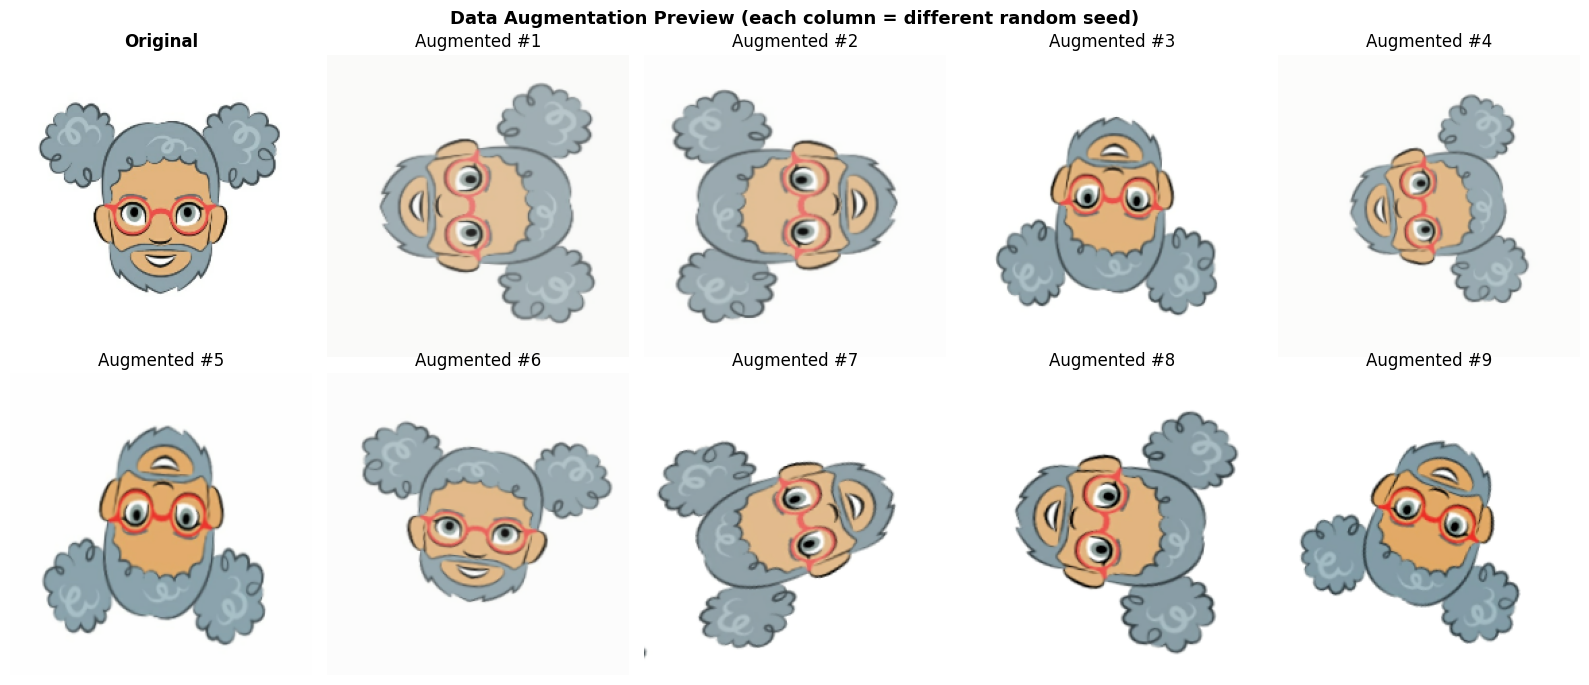

Sample class: cartoon | Augmentation demo saved → models/augmentation_demo.png


In [14]:
# Visualise augmentation effects on a sample image (picks first training image)
if train_rows:
    sample_path, sample_label = train_rows[0]
    raw   = tf.io.read_file(sample_path)
    img   = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img   = tf.image.resize(img, TL_IMG_SIZE)
    img   = tf.cast(img, tf.float32)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle('Data Augmentation Preview (each column = different random seed)',
                 fontsize=13, fontweight='bold')

    axes[0, 0].imshow(img.numpy().astype(np.uint8))
    axes[0, 0].set_title('Original', fontweight='bold')
    axes[0, 0].axis('off')

    class_name = 'cartoon' if sample_label == 0 else 'real'

    for i in range(1, 10):
        aug_img, _ = _augment(img, tf.constant(0.0))
        row, col = divmod(i, 5)
        axes[row, col].imshow(aug_img.numpy().clip(0, 255).astype(np.uint8))
        axes[row, col].set_title(f'Augmented #{i}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('models/augmentation_demo.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Sample class: {class_name} | Augmentation demo saved → models/augmentation_demo.png')
else:
    print('No training images available — skipping augmentation demo.')

---
## Section 7 — Transfer Learning Model (MobileNetV2)

In [15]:
def build_transfer_model(phase: int = 1) -> tf.keras.Model:
    """
    MobileNetV2 backbone + explicit custom head.

    Phase 1: ALL backbone layers frozen → head-only training  (LR=1e-4)
    Phase 2: Last 30 layers unfrozen    → fine-tuning         (LR=1e-5)
    """
    backbone = MobileNetV2(
        input_shape=(*TL_IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    if phase == 1:
        backbone.trainable = False
        logger.info('  Phase 1: backbone fully frozen (%d layers)', len(backbone.layers))
    else:
        backbone.trainable = True
        for layer in backbone.layers[:-30]:
            layer.trainable = False
        n = sum(1 for l in backbone.layers if l.trainable)
        logger.info('  Phase 2: %d backbone layers unfrozen', n)

    inputs  = tf.keras.Input(shape=(*TL_IMG_SIZE, 3), name='input_image')
    x       = backbone(inputs, training=(phase == 2))
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           name='dense_128')(x)
    x       = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='sigmoid_out')(x)

    model = models.Model(inputs, outputs, name=f'mobilenetv2_tl_p{phase}')
    lr    = 1e-4 if phase == 1 else 1e-5
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model


# Preview architecture
tl_model_preview = build_transfer_model(phase=1)
tl_model_preview.summary()

18:12:59 [INFO]   Phase 1: backbone fully frozen (154 layers)


Model: "mobilenetv2_tl_p1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sigmoid_out (Dense)                  │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## Section 8 — CNN From Scratch Architecture

In [16]:
def build_scratch_cnn(img_size: tuple = SC_IMG_SIZE) -> tf.keras.Model:
    """
    Custom CNN built entirely from scratch — zero pretrained weights.

    Architecture:
      Input (128×128×3)
        Block 1: Conv2D(32)  → BN → ReLU → MaxPool
        Block 2: Conv2D(64)  → BN → ReLU → MaxPool
        Block 3: Conv2D(128) → BN → ReLU → MaxPool
        Block 4: Conv2D(256) → BN → ReLU → MaxPool
        Flatten → Dense(512) → Dropout(0.5)
               → Dense(256) → Dropout(0.4)
               → Dense(1, sigmoid)
    """
    inputs = tf.keras.Input(shape=(*img_size, 3), name='input')

    # Block 1: 32 filters
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)   # 64×64×32

    # Block 2: 64 filters
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)   # 32×32×64

    # Block 3: 128 filters
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)   # 16×16×128

    # Block 4: 256 filters
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)
    x = layers.MaxPooling2D((2,2), name='pool4')(x)   # 8×8×256

    # Fully-connected head
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='dense_512')(x)
    x = layers.Dropout(0.5, name='dropout_05')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='dense_256')(x)
    x = layers.Dropout(0.4, name='dropout_04')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='sigmoid_out')(x)

    model = models.Model(inputs, outputs, name='scratch_cnn')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model


scratch_model_preview = build_scratch_cnn()
scratch_model_preview.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 128, 128, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 128, 128, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu1 (Activation)                   │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 64, 64, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu2 (Activation)                   │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 32, 32, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 32, 32, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu3 (Activation)                   │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv4 (Conv2D)                       │ (None, 16, 16, 256)         │         294,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn4 (BatchNormalization)             │ (None, 16, 16, 256)         │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu4 (Activation)                   │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool4 (MaxPooling2D)                 │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_512 (Dense)                    │ (None, 512)                 │       8,389,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_05 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                    │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 8,910,561 (33.99 MB)

 Trainable params: 8,909,601 (33.99 MB)

 Non-trainable params: 960 (3.75 KB)

---
## Section 9 — Training

In [17]:
# ── Build tf.data pipelines ─────────────────────────────────────────────────
preprocess_tl      = lambda img: preprocess_input(img)
preprocess_scratch = lambda img: tf.cast(img, tf.float32) / 255.0

tl_train_ds = make_dataset(train_rows, TL_IMG_SIZE, BATCH_SIZE, preprocess_tl, augment=True)
tl_val_ds   = make_dataset(val_rows,   TL_IMG_SIZE, BATCH_SIZE, preprocess_tl)
tl_test_ds  = make_dataset(test_rows,  TL_IMG_SIZE, BATCH_SIZE, preprocess_tl)

sc_train_ds = make_dataset(train_rows, SC_IMG_SIZE, BATCH_SIZE, preprocess_scratch, augment=True)
sc_val_ds   = make_dataset(val_rows,   SC_IMG_SIZE, BATCH_SIZE, preprocess_scratch)
sc_test_ds  = make_dataset(test_rows,  SC_IMG_SIZE, BATCH_SIZE, preprocess_scratch)

print('tf.data pipelines ready.')
print(f'  TL  — train batches: {len(tl_train_ds)}, val: {len(tl_val_ds)}')
print(f'  SCR — train batches: {len(sc_train_ds)}, val: {len(sc_val_ds)}')

tf.data pipelines ready.
  TL  — train batches: 50, val: 11
  SCR — train batches: 50, val: 11


In [ ]:
def _fmt(s):
    m, s2 = divmod(int(s), 60); h, m = divmod(m, 60)
    return f'{h}h {m}m {s2}s' if h else f'{m}m {s2}s'


def get_callbacks(model_path):
    return [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, verbose=1),
        callbacks.ModelCheckpoint(model_path, save_best_only=True,
                                  monitor='val_accuracy', verbose=1),
    ]

# ── Transfer Learning — Phase 1 ─────────────────────────────────────────────
print('=' * 60)
print('PHASE 1 — Head-only training (backbone frozen)')
print('=' * 60)
tl_model = build_transfer_model(phase=1)
t0 = time.time()
h1 = tl_model.fit(tl_train_ds, epochs=EPOCHS_P1,
                   validation_data=tl_val_ds,
                   callbacks=get_callbacks(TL_MODEL_PATH))
t_p1 = time.time() - t0
print(f'  Phase 1 done in {_fmt(t_p1)}')

PHASE 1 — Head-only training (backbone frozen)


18:13:03 [INFO]   Phase 1: backbone fully frozen (154 layers)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.8397 - auc: 0.9035 - loss: 0.3817 - precision: 0.8265 - recall: 0.8703
Epoch 1: val_accuracy improved from None to 1.00000, saving model to models/real_vs_cartoon_classifier.keras

Epoch 1: finished saving model to models/real_vs_cartoon_classifier.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 998ms/step - accuracy: 0.9439 - auc: 0.9891 - loss: 0.2043 - precision: 0.9388 - recall: 0.9548 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0374 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
32/50 ━━━━━━━━━━━━━━━━━━━━ 15s 868ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0423 - precision: 1.0000 - recall: 1.0000

In [ ]:
# ── Transfer Learning — Phase 2 ─────────────────────────────────────────────
print('=' * 60)
print('PHASE 2 — Fine-tuning last 30 backbone layers')
print('=' * 60)

backbone_layer = tl_model.layers[1]  # MobileNetV2 backbone
backbone_layer.trainable = True
for layer in backbone_layer.layers[:-30]:
    layer.trainable = False
for layer in backbone_layer.layers[-30:]:
    layer.trainable = True

n_trainable = sum(1 for l in backbone_layer.layers if l.trainable)
print(f'  Backbone layers unfrozen: {n_trainable}')

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

t1 = time.time()
h2 = tl_model.fit(tl_train_ds, epochs=EPOCHS_P2,
                   validation_data=tl_val_ds,
                   callbacks=get_callbacks(TL_MODEL_PATH))
tl_model_ft = tl_model  
t_p2   = time.time() - t1
t_total_tl = t_p1 + t_p2
print(f'  Phase 2 done in {_fmt(t_p2)}  |  Total: {_fmt(t_total_tl)}')

In [ ]:
# ── CNN from Scratch ────────────────────────────────────────────────────────
print('=' * 60)
print('TRAINING CNN FROM SCRATCH')
print('=' * 60)
scratch_model = build_scratch_cnn()
t0 = time.time()
h_sc = scratch_model.fit(
    sc_train_ds, epochs=EPOCHS_SCRATCH,
    validation_data=sc_val_ds,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=4, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(SC_MODEL_PATH, save_best_only=True,
                                  monitor='val_accuracy', verbose=1),
    ]
)
t_sc = time.time() - t0
print(f'  Scratch CNN done in {_fmt(t_sc)}')

---
## Section 10 — Evaluation

In [ ]:
def get_predictions(model, test_ds):
    """Run inference and collect ground-truth + probabilities."""
    y_true, y_prob = [], []
    for batch_imgs, batch_labels in test_ds:
        probs = model.predict(batch_imgs, verbose=0).flatten()
        y_prob.extend(probs.tolist())
        y_true.extend(batch_labels.numpy().tolist())
    return np.array(y_true, dtype=int), np.array(y_prob, dtype=np.float32)


def compute_metrics(y_true, y_pred, y_prob) -> dict:
    acc = accuracy_score(y_true, y_pred)
    p   = precision_score(y_true, y_pred, zero_division=0)
    r   = recall_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return {'accuracy': round(float(acc), 4), 'precision': round(float(p), 4),
            'recall': round(float(r), 4), 'f1_score': round(float(f1), 4),
            'auc': round(float(roc_auc), 4), '_fpr': fpr, '_tpr': tpr}


# Load best saved model before evaluating (full model load — avoids weight mismatch)
if os.path.exists(TL_MODEL_PATH):
    tl_model_ft = tf.keras.models.load_model(TL_MODEL_PATH)
    logger.info('TL model loaded from %s', TL_MODEL_PATH)
if os.path.exists(SC_MODEL_PATH):
    scratch_model = tf.keras.models.load_model(SC_MODEL_PATH)
    logger.info('Scratch model loaded from %s', SC_MODEL_PATH)

# Get predictions
tl_true, tl_prob = get_predictions(tl_model_ft, tl_test_ds)
sc_true, sc_prob = get_predictions(scratch_model, sc_test_ds)

tl_pred = (tl_prob >= 0.5).astype(int)
sc_pred = (sc_prob >= 0.5).astype(int)

tl_metrics = compute_metrics(tl_true, tl_pred, tl_prob)
sc_metrics = compute_metrics(sc_true, sc_pred, sc_prob)

CLASS_NAMES = ['Cartoon', 'Real']
print('Transfer Learning — Classification Report:')
print(classification_report(tl_true, tl_pred, target_names=CLASS_NAMES))
print('\nCNN from Scratch — Classification Report:')
print(classification_report(sc_true, sc_pred, target_names=CLASS_NAMES))

---
## Section 11 — ROC Curve

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tl_metrics['_fpr'], tl_metrics['_tpr'], color='#3498db', lw=2,
        label=f"Transfer Learning (AUC = {tl_metrics['auc']:.3f})")
ax.plot(sc_metrics['_fpr'], sc_metrics['_tpr'], color='#e74c3c', lw=2,
        label=f"CNN from Scratch  (AUC = {sc_metrics['auc']:.3f})")
ax.plot([0, 1], [0, 1], color='#aaa', lw=1, ls='--', label='Random baseline')

ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('models/roc_curve.png', dpi=150)
plt.show()
print('ROC curve saved → models/roc_curve.png')

---
## Section 12 — Confusion Matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, out_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > thresh else 'black')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'  Saved → {out_path}')


plot_confusion_matrix(tl_true, tl_pred, 'Transfer Learning (MobileNetV2)',
                      'models/confusion_matrix_tl.png')
plot_confusion_matrix(sc_true, sc_pred, 'CNN from Scratch',
                      'models/confusion_matrix_scratch.png')

---
## Section 13 — Metrics Comparison

In [ ]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1_score', 'auc']

print('\n' + '='*60)
print('MODEL COMPARISON TABLE')
print('='*60)
print(f'{"Metric":<18}  {"Transfer Learning":>20}  {"CNN Scratch":>15}')
print('-'*60)
for k in metrics_keys:
    tl_v = tl_metrics.get(k, 'N/A')
    sc_v = sc_metrics.get(k, 'N/A')
    print(f'{k:<18}  {str(tl_v):>20}  {str(sc_v):>15}')
print('='*60)

# Bar chart comparison
tl_vals = [tl_metrics[k] for k in metrics_keys]
sc_vals = [sc_metrics[k] for k in metrics_keys]

x = np.arange(len(metrics_keys))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, tl_vals, w, label='Transfer Learning', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, sc_vals, w, label='CNN from Scratch',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([k.replace('_', ' ').title() for k in metrics_keys])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('models/metrics_comparison.png', dpi=150)
plt.show()

# Save JSON
tl_metrics_clean = {k: v for k, v in tl_metrics.items() if not k.startswith('_')}
sc_metrics_clean = {k: v for k, v in sc_metrics.items() if not k.startswith('_')}
comparison = {'transfer_learning': tl_metrics_clean, 'scratch_cnn': sc_metrics_clean}
with open('models/metrics_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print('Comparison saved → models/metrics_comparison.json')

---
## Section 14 — Inference Demo

In [ ]:
def predict_single(image_path: str, model, img_size, preprocess_fn, label='model') -> dict:
    """
    Run inference on a single image file.

    Returns dict with predicted class, confidence, and raw probability.
    """
    img = cv2.imread(image_path)
    if img is None:
        return {'error': f'Cannot read {image_path}'}

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rs  = cv2.resize(img_rgb, img_size)
    img_f   = preprocess_fn(img_rs.astype(np.float32))
    prob    = float(model.predict(np.expand_dims(img_f, 0), verbose=0)[0][0])

    predicted = 'real' if prob >= 0.5 else 'cartoon'
    conf      = max(prob, 1 - prob) * 100

    return {'label': predicted, 'confidence': round(conf, 1),
            'raw_prob_real': round(prob, 4)}


# Demo: run on first test images from each class
from sklearn.preprocessing import FunctionTransformer

demo_images = [r for r in test_rows if r[1] == 0][:2] + \
              [r for r in test_rows if r[1] == 1][:2]

print('Inference Demo — Transfer Learning model:')
print('-' * 55)
for path, true_label in demo_images:
    result = predict_single(path, tl_model_ft, TL_IMG_SIZE, preprocess_tl)
    true_name = 'cartoon' if true_label == 0 else 'real'
    match = '✓' if result['label'] == true_name else '✗'
    print(f'  {match} True: {true_name:8s} | Pred: {result["label"]:8s} '
          f'| Conf: {result["confidence"]}%')

print('\nNote: run predict_single() with your own image path for custom inference.')

---
## Section 15 — Flask Integration Notes

The Flask app (`app.py`) provides the web interface. **No modifications are needed.**

### Running the App
```bash
python app.py   # → http://localhost:5000
```

### API Endpoint
```
POST /process
Content-Type: multipart/form-data

Fields:
  image   — image file (PNG, JPG, WEBP, BMP)
  method  — "all" | "standard" | "advanced" | "sketch"  (default: "all")
```

### Response JSON
```json
{
  "classification": { "label": "real", "confidence": 92.3, "neural_score": 0.923 },
  "already_cartoon": false,
  "timing": { "classify_ms": 120, "cartoonize_ms": 340, "total_ms": 460 },
  "results": { "standard": "<base64>", "advanced": "<base64>", "sketch": "<base64>" }
}
```

### Model Files Used by Flask
| File | Purpose |
|------|---------|
| `models/real_vs_cartoon_classifier.h5` | Transfer Learning classifier |
| `templates/index.html` | Web UI (untouched) |
| `static/output/` | Cartoonized output saved here |

> The Flask app uses the **Transfer Learning** model for classification and applies the 3-method cartoonization pipeline (Standard → Bilateral filter, Advanced → K-means HSV, Sketch → Pencil sketch).